# Bayesian Calibration of Stochastic Volatility Models via Flow-Augmented MCMC

### Author: Mihail Dimitrov (SID: 3037621433) | 2 May 2026

The stochastic volatility (SV) model is the canonical Bayesian problem in quantitative finance, in which log-volatility evolves as a latent $\text{AR}(1)$ process and is inferred from daily log-returns. This notebook implements and compares three Bayesian samplers for it:
1. **Kim-Shephard-Chib mixture-of-normals Gibbs**: the practitioner gold standard, used as ground truth.
2. **NUTS** as implemented in PyMC: strong general-purpose baseline.
3. **Flow-augmented MCMC**: alternating local MALA moves with online training of a rational-quadratic spline flow, which is then used as an independent proposal in subsequent MH steps (Gabrié et al., 2022).

All three samplers are run on a simulated SV process with known parameters (for posterior recovery), the S&P 500, and AAPL (ten-year daily windows). Comparisons cover mixing efficiency (ESS/sec), posterior agreement (Wasserstein distance to KSC ground truth), and downstream accuracy (posterior-predictive Value-at-Risk forecasts backtested via the Kupiec test).

### Table of Contents

- [1. Data Loading & Preprocessing](#1-data-loading--preprocessing)
- [2. Simulated SV Truth Set](#2-generate-simulated-data-truth-set)
- [3. KSC Mixture-of-Normals Gibbs](#3-ksc-mixture-of-normals-gibbs-sampler)
- [4. NUTS via PyMC](#4-nuts-via-pymc)
- [5. Flow-Augmented MCMC](#5-flow-augmented-mcmc)
- [6. Comparison & Metrics](#6-comparison-metrics)
- [7. Conclusion](#7-conclusion)

# 0. Install Dependencies & Load Constants

This setup cell loads the project configuration, plotting utilities, inference functions, and external libraries used throughout the notebook. Keeping constants such as priors, simulation truth values, sampler settings, and random seeds in `src/config.py` makes the later steps easier to reproduce and compare.


In [1]:
%load_ext autoreload
%autoreload 2

# Install dependencies
!pip install -q -r requirements.txt

import time
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")

import numpy as np
import pandas as pd

import yfinance as yf
yf.set_tz_cache_location("./yf_cache")

from scipy.stats import norm
from pytensor import scan, tensor as pt
import pymc as pm

from src.config import *
from src.diagnostics import (
    sanity_plots,
    display_sampler_diagnostics,
    plot_latent_recovery,
    display_flow_diagnostics,
)
from src.flow_mcmc import run_flow_mcmc
from src.ksc_gibbs import run_ksc_chains, save_ksc_result
from src.comparison import (
    load_all_sampler_results,
    ess_per_second_table,
    wasserstein_distance_table,
    var_forecast_table,
    kupiec_backtest_table,
    plot_ess_per_second,
    plot_wasserstein,
    plot_kupiec_exceedance_rates,
)

General
────────────────────────────────────────────────────────────
  SEED                      = 42
  MODAL_GPU                 = 'B200'

Step 1 (Data)
────────────────────────────────────────────────────────────
  STOCK_LIST                = ['^GSPC', 'AAPL']
  START_DATE                = '2016-01-01'
  END_DATE                  = '2026-01-01'

Step 2 (Simulation)
────────────────────────────────────────────────────────────
  MU_TRUE                   = -9.0
  PHI_TRUE                  = 0.97
  SIGMA_ETA_TRUE            = 0.15
  T_SIM                     = 2500

Step 3 (KSC)
────────────────────────────────────────────────────────────
  PRIOR_MU_VAR              = 100.0
  PRIOR_PHI_BETA            = (20.0, 1.5)
  PRIOR_SIGMA_ETA_GAMMA     = (2.5, 0.025)
  KSC_Q                     = array shape=(7,), mean=+0.1429
  KSC_M                     = array shape=(7,), mean=-2.6522
  KSC_V2                    = array shape=(7,), mean=+2.2856
  KSC_N_CHAINS              = 4
  KSC_N_ITER      

## 1. Data Loading & Preprocessing
We load S&P 500 (^GSPC) and Apple (AAPL) data from `yfinance`. Preprocessing includes calculating and demeaning log returns for both series. A $2 \times 2$ panel of diagnostic plots is constructed for each time series to briefly analyze the data and its autocorrelation up to 50 lags. This includes:
1. A time series plot of log-returns over time.
2. A histogram plot to better visualize the data distribution, which should have heavier tails than a Gaussian.
3. An $\text{ACF}(y)$ plot, which should be near-zero for positive lags, reflecting that past returns do not predict future returns (a hallmark of efficient markets).
4. An $\text{ACF}(y^2)$ plot, which should decay slowly toward zero rather than drop immediately, reflecting the tendency for turbulent days to follow turbulent days known as **volatility clustering**. This is precisely the empirical fact the $\text{AR}(1)$ on $h_t$ in the SV model will later capture in [Step 2](#2-generate-simulated-data-truth-set).

Ticker          AAPL         ^GSPC
count   2.513000e+03  2.513000e+03
mean   -4.638815e-19 -4.390307e-19
std     1.828132e-02  1.145105e-02
min    -1.386778e-01 -1.281393e-01
25%    -8.074736e-03 -4.106191e-03
50%     1.243416e-04  2.697136e-04
75%     9.008085e-03  5.296413e-03
max     1.416475e-01  9.040776e-02


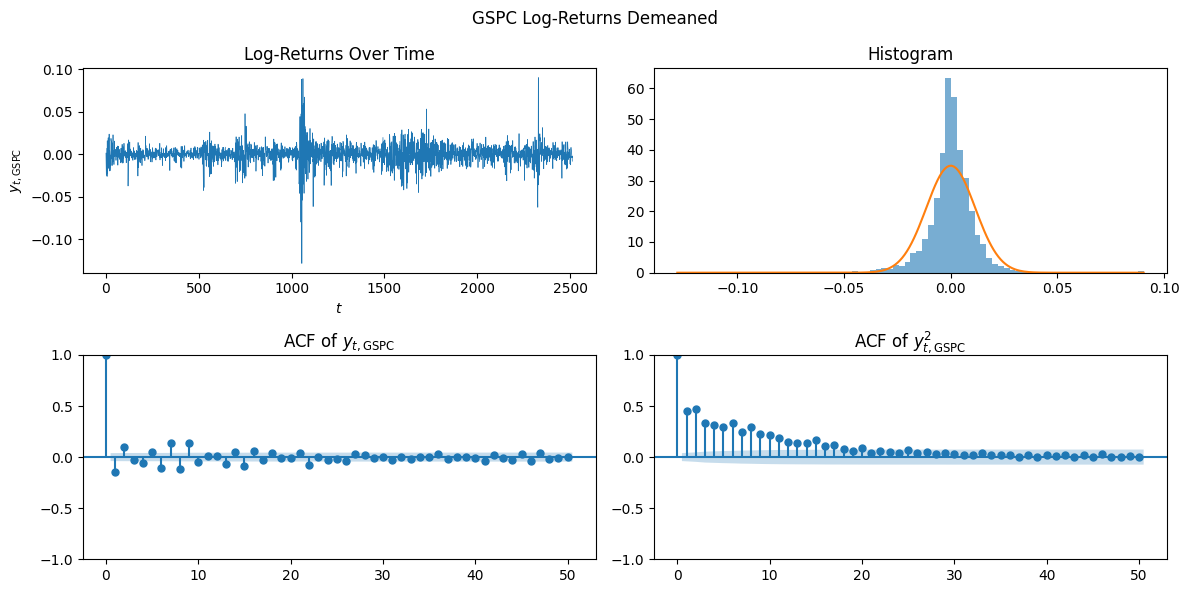

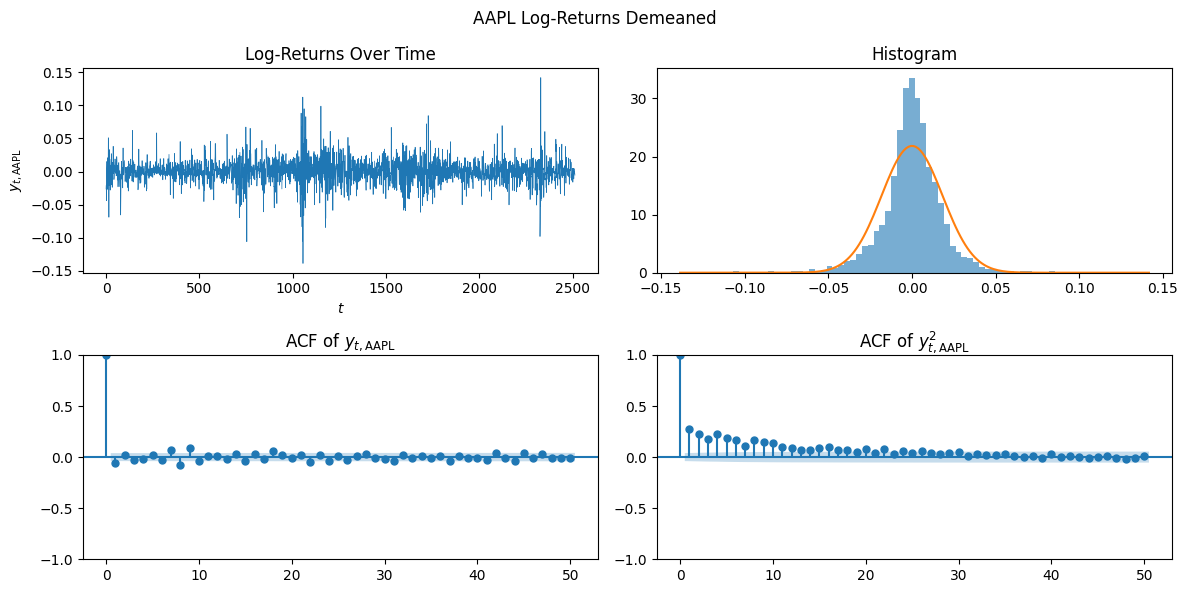

In [3]:
data = yf.download(
    STOCK_LIST,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,   # use adjusted close, splits/dividends folded in
    progress=False,
)

close = data["Close"]
log_returns = np.log(close).diff().dropna()
log_returns_demeaned = log_returns - log_returns.mean()

print(log_returns_demeaned.describe())
sanity_plots(log_returns_demeaned["^GSPC"], "GSPC Log-Returns Demeaned", r"y_{t, \mathrm{GSPC}}")
sanity_plots(log_returns_demeaned["AAPL"], "AAPL Log-Returns Demeaned", r"y_{t, \mathrm{AAPL}}")

---

## 2. Generate Simulated Data (Truth Set)

Before applying any inference algorithm to real market data, we test it on data where we *already know the answer*. If a sampler cannot recover the parameters that generated a synthetic series, then its real-data posterior should not be trusted until the implementation is checked. This simulated experiment is therefore a debugging step as much as a validation step.

We generate $T = 2500$ days (~10 trading years) from the **stochastic volatility (SV) model** that the rest of the project will calibrate. The model has two equations:

$$
\begin{aligned}
h_t &= \mu + \phi\,(h_{t-1} - \mu) + \sigma_\eta\, \eta_t, &\quad \eta_t &\overset{\text{iid}}{\sim} \mathcal{N}(0, 1) & &\text{(latent state)} \\
y_t &= e^{h_t / 2}\, \epsilon_t, &\quad \epsilon_t &\overset{\text{iid}}{\sim} \mathcal{N}(0, 1) & &\text{(observation)}
\end{aligned}
$$

- $h_t$ is the **log-volatility**, which we never observe directly. It evolves as an **$\mathbf{AR(1)}$ process**: today's $h_t$ is a weighted average of yesterday's $h_{t-1}$ and a long-run mean $\mu$, plus Gaussian noise.
- $y_t$ is the **observed log-return** on day $t$. Its *scale* is set by $e^{h_t/2}$. When log-volatility $h_t$ is high, days are turbulent; when it's low, days are calm(er). It is imperative to note that $y_t \mid h_t$ is Gaussian, but its variance changes every day.

A note on the last sentence. If volatility were constant, returns would be plain Gaussian and the ACF of $y_t^2$ would be zero at every positive lag. The slow decay we saw in [Step 1](#1-data-loading--preprocessing)'s ACF($y^2$) plot is exactly what an $\text{AR}(1)$ on $h_t$ produces: high $\phi \implies$ today's volatility is close to yesterday's $\implies$ volatility clusters $\implies$ ACF of $y^2$ decays slowly.


The three parameters control how the latent path behaves:

| Symbol | Distribution | Meaning | Truth Value | Intuition |
|---|---|---|---|---|
| $\mu$ | $\mu \sim \mathcal{N}(0, 10^2)$ | Long-run mean of volatility $h_t$ | $-9.0$ | Typical daily volatility is $e^{-9/2} \approx 1.1\%$ (realistic for an index). |
| $\phi$ | $(\phi + 1)/2 \sim \text{Beta}(20, 1.5)$ | Persistence  | $0.97$ | A shock to volatility decays slowly, whereas turbulent days cluster. |
| $\sigma_\eta$ | $\sigma_\eta^2 \sim \mathcal{IG}(2.5, 0.025)$ | Size of daily shocks to log-volatility | $0.15$ | Log-volatility drifts modestly day-to-day, with occasional larger jumps. |

### Initial Condition

We draw $h_0$ from the **stationary distribution** of the $\text{AR}(1)$:

$$
h_0 \;\sim\; \mathcal{N}\!\left(\mu,\;\frac{\sigma_\eta^2}{1 - \phi^2}\right).
$$

Starting from the stationary distribution means the simulated series has no startup transient. It looks like a window of volatility we extrapolated from the middle of a long history, not the first few days after an arbitrary initial guess.

### What we keep

`simulate_sv` returns both `y_sim` (observed returns) and `h_sim` (the true latent path). In real applications $h$ is unobservable; we hold onto it here for the sole reason that, after running each sampler, we can check whether the posterior 95% credible bands for $h_t$ actually contain the truth.

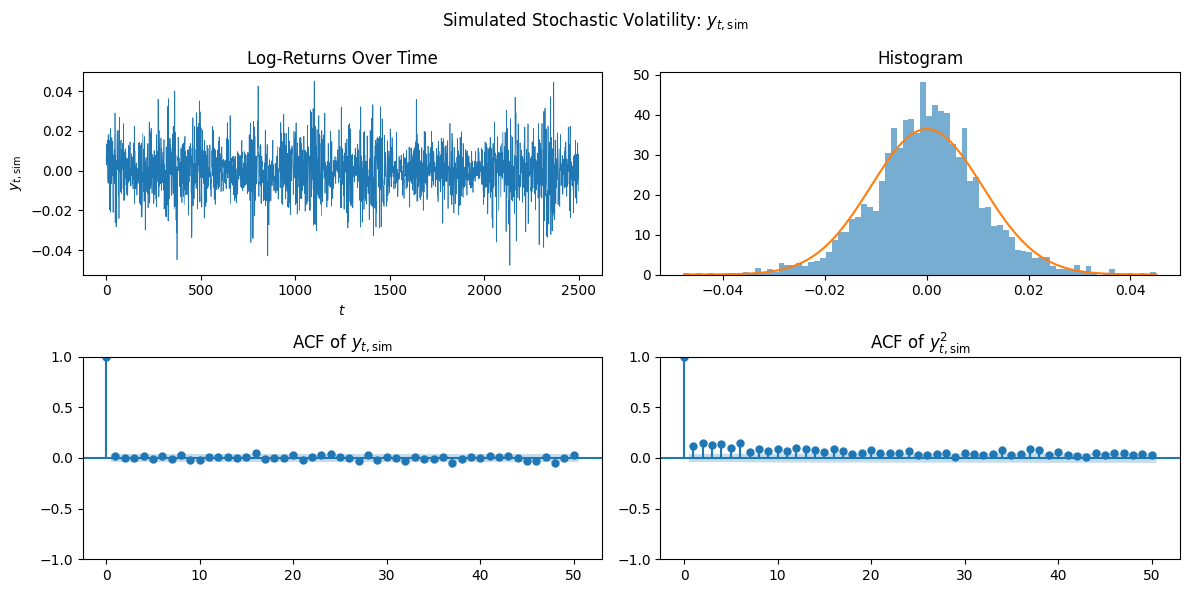

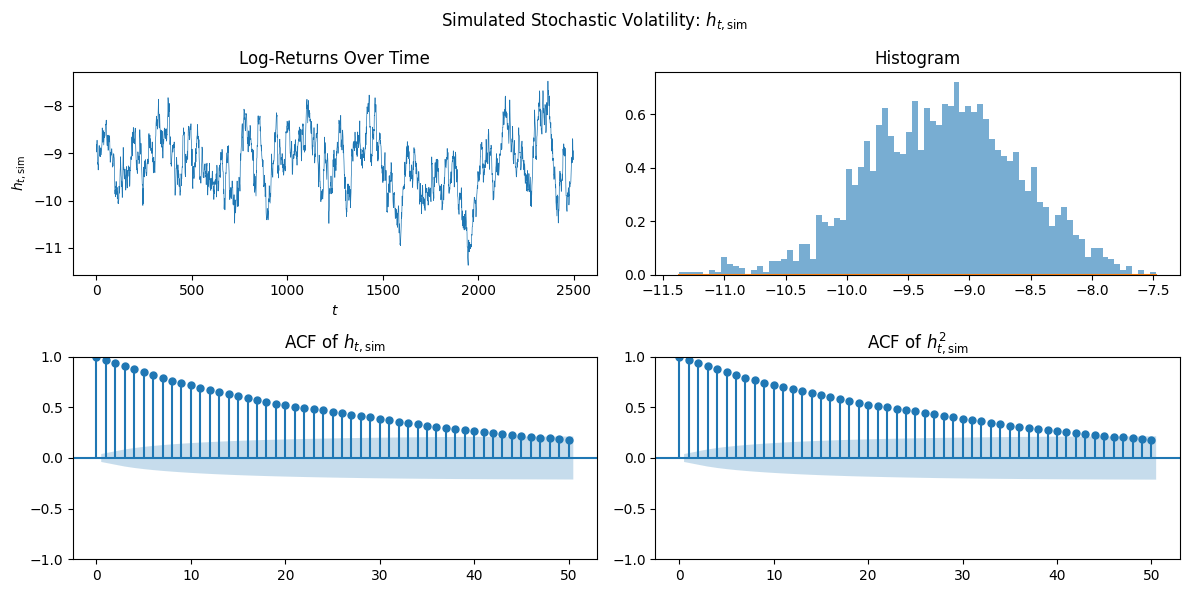

In [4]:
def simulate_sv(T, mu, sigma_eta, phi):
    rng = np.random.default_rng(SEED)
    h = np.empty(T)
    h[0] = norm.rvs(loc=mu, scale=np.sqrt(sigma_eta**2 / (1 - phi**2)), random_state=rng)
    for t in range(1, T):
        h[t] = mu + phi*(h[t-1] - mu) + sigma_eta * norm.rvs(random_state=rng)
    y = np.exp(h / 2) * norm.rvs(size=T, random_state=rng)
    return y, h

y_sim, h_sim = simulate_sv(T_SIM, MU_TRUE, SIGMA_ETA_TRUE, PHI_TRUE)

sanity_plots(y_sim, r"Simulated Stochastic Volatility: $y_{t, \mathrm{sim}}$", r"y_{t, \mathrm{sim}}")
sanity_plots(h_sim, r"Simulated Stochastic Volatility: $h_{t, \mathrm{sim}}$", r"h_{t, \mathrm{sim}}")

The plots above mirror [Step 1](#1-data-loading--preprocessing): time series + histogram + $\mathrm{ACF}(y)$ + $\mathrm{ACF}(y^2)$ for the simulated returns, then the same panel for the latent path. The $\mathrm{ACF}(y_{\rm sim}^2)$ should decay slowly since that is what is produced by volatility clustering the $\mathrm{AR}(1)$ on $h_t$.

---

## 3. KSC Mixture-of-Normals Gibbs Sampler

KSC Gibbs is the specialized benchmark sampler for this project. NUTS ([Step 4](#4-nuts-via-pymc)) and flowMC ([Step 5](#5-flow-augmented-mcmc)) are both evaluated against the posterior produced here. I treat KSC as the main reference because it is designed specifically for the stochastic volatility model and exploits the state-space structure that the other samplers have to handle more generally.

The implementation for this section lives in `src/ksc_gibbs.py`.

### Why the SV Posterior Is Difficult

Recall the stochastic volatility model from [Step 2](#2-generate-simulated-data-truth-set):

$$
y_t = \exp(h_t / 2)\epsilon_t, \qquad \epsilon_t \sim N(0,1),
$$

$$
h_t = \mu + \phi(h_{t-1} - \mu) + \sigma_\eta \eta_t, \qquad \eta_t \sim N(0,1).
$$

The latent volatility equation is linear and Gaussian, but the observation equation is not. The return variance depends multiplicatively on the unobserved log-volatility $h_t$, so the posterior for the latent path is not available in closed form.

The second difficulty is persistence. In financial volatility data, $\phi$ is usually close to one, which means adjacent latent states are strongly correlated. A sampler that updates each $h_t$ one at a time would move very slowly. The main appeal of KSC Gibbs is that it avoids this by sampling the entire latent volatility path jointly.

### KSC Mixture Augmentation

Kim, Shephard, and Chib (1998) use a transformation and mixture approximation to turn the model into a conditionally linear-Gaussian state-space model.

First, square the returns and take logs:

$$
z_t = \log(y_t^2 + c)
    = h_t + \log(\epsilon_t^2).
$$

The small constant $c$ avoids numerical problems when $y_t$ is close to zero.

This transformation makes the observation equation additive in $h_t$. The remaining problem is that the noise term $\log(\epsilon_t^2)$ is not Gaussian. It follows a $\log \chi_1^2$ distribution, which is skewed and heavy-tailed.

KSC approximate this non-Gaussian error with a seven-component Gaussian mixture. Introducing mixture indicators

$$
s_t \in \{1,\ldots,7\}
$$

makes the observation equation Gaussian conditional on $s_t$. Once the mixture states are known, the model becomes conditionally linear-Gaussian, so the latent path can be sampled with a forward-filter backward-sample update.

### Gibbs Sampling Blocks

Each Gibbs sweep cycles through five conditional updates:

| Block | Quantity sampled | Method |
|---|---|---|
| 1 | $s_{1:T} \mid h, z$ | A 7-way categorical at each time point, independent across time |
| 2 | $h_{1:T} \mid s, \theta, z$ | **Forward-filter backward-sample (FFBS)** - the entire latent path in one joint draw |
| 3 | $\mu \mid h, \phi, \sigma_\eta^2$ | Gaussian conditional update |
| 4 | $\sigma_\eta^2 \mid h, \mu, \phi$ | Inverse-Gamma conditional update |
| 5 | $\phi \mid h, \mu, \sigma_\eta^2$ | Metropolis-Hastings update |

The most important block is the FFBS update for $h_{1:T}$. Instead of updating the latent states one at a time, KSC samples the full $T$-dimensional volatility path jointly. This directly addresses the strong serial dependence in the latent state process.

The only accept/reject step is the update for $\phi$, because the stationarity restriction and prior make its conditional distribution non-conjugate.

### Output Format

After running the KSC chains, the sampler saves posterior draws for $(\mu, \phi, \sigma_\eta)$, along with latent-volatility summaries such as `h_mid`, `h_last`, and `h_mean`. These outputs are saved to `samples/*.npz` so that the comparison section can load all samplers in the same format.

KSC is also used as the reference distribution for the Wasserstein comparisons in [Step 6](#6-comparison-metrics). This does not mean KSC is exact ground truth: it still has Monte Carlo error and the small KSC mixture approximation. But for this model, it is the strongest specialized benchmark available in the project.

### Diagnostics

This section first runs KSC on the simulated data from [Step 2](#2-generate-simulated-data-truth-set), where the true values of $\mu$, $\phi$, and $\sigma_\eta$ are known. This checks whether the sampler can recover the data-generating parameters.

Then the same sampler is run on the SPX and AAPL log returns from [Step 1](#1-data-loading--preprocessing). The resulting posterior draws are used later to compare mixing efficiency, posterior agreement, and downstream VaR forecasts across KSC, NUTS, and flowMC.


In [6]:
# Run KSC on simulated data
ksc_sim = run_ksc_chains(
    y_sim,
    n_chains=KSC_N_CHAINS,
    n_iter=KSC_N_ITER,
    n_burn=KSC_N_BURN,
    prior_mu_var=PRIOR_MU_VAR,
    prior_sigma2_eta_gamma=PRIOR_SIGMA_ETA_GAMMA,
    prior_phi_beta=PRIOR_PHI_BETA,
    q=KSC_Q,
    m=KSC_M,
    v2=KSC_V2,
    seed=SEED,
    verbose=True
)

KSC Gibbs: 100%|██████████| 120000/120000 [02:00<00:00, 996.01it/s, chain=4/4, mu=-9.190, phi=0.9637, seed=45, sigma_eta=0.158] 


KSC SIM


,mean,sd,2.5%,97.5%,truth,in CI
param,,,,,,
mu,-9.221889,0.114576,-9.446201,-8.994098,-9.00,True
phi,0.968979,0.008349,0.950577,0.983336,0.97,True
sigma_eta,0.160437,0.020528,0.123248,0.204542,0.15,True


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-9.222,0.115,-9.442,-9.010,0.000,0.000,56559.0,73853.0,1.00
phi,0.969,0.008,0.954,0.984,0.000,0.000,1038.0,2567.0,1.00
sigma_eta,0.160,0.021,0.123,0.200,0.001,0.000,565.0,1089.0,1.01
h_mid,-9.143,0.346,-9.784,-8.482,0.002,0.001,30128.0,49602.0,1.00
h_last,-9.476,0.422,-10.250,-8.657,0.002,0.001,29217.0,53291.0,1.00


mu           469.451404
phi            8.615615
sigma_eta      4.689617
h_mid        250.068634
h_last       242.507146
Name: ess_bulk_per_sec, dtype: float64

accept_phi: [0.95076 0.94768 0.949   0.94824]
Elapsed seconds: 120.47892395899544


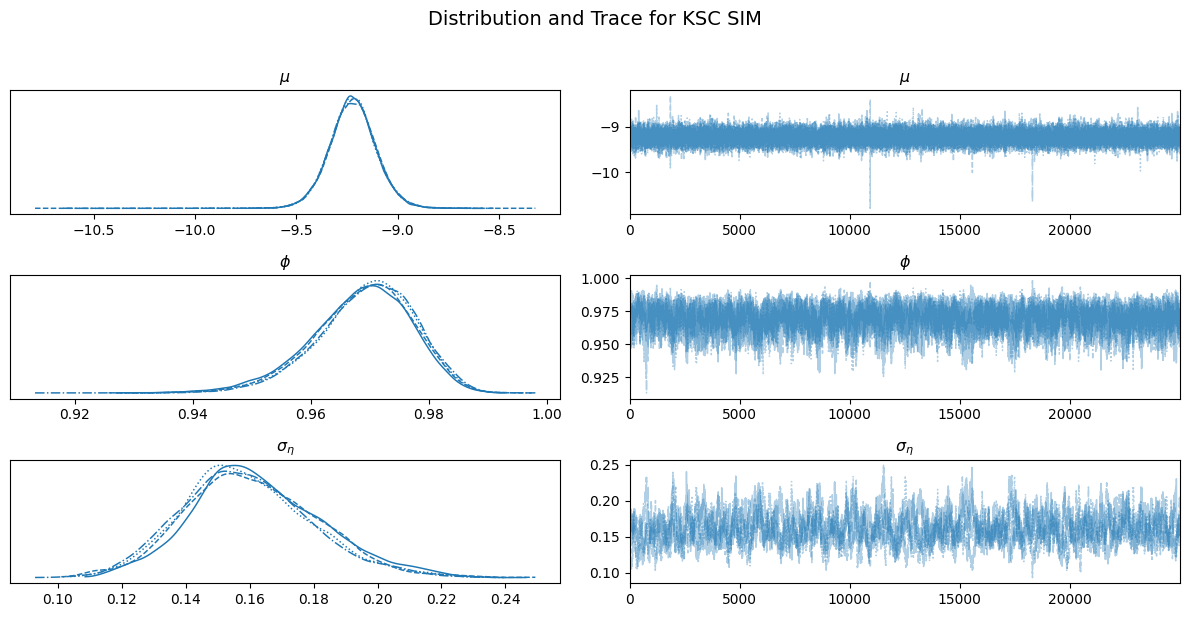

In [7]:
ksc_sim_idata = display_sampler_diagnostics(
    "KSC SIM",
    ksc_sim,
    truth={"mu": MU_TRUE, "phi": PHI_TRUE, "sigma_eta": SIGMA_ETA_TRUE},
    accept_key="accept_phi"
)

KSC does a good job on the simulated data. The true values of $\mu$, $\phi$, and $\sigma_\eta$ are inside the posterior intervals, so the sampler seems to be recovering the parameters correctly.

h coverage: 0.971
h RMSE:     0.309


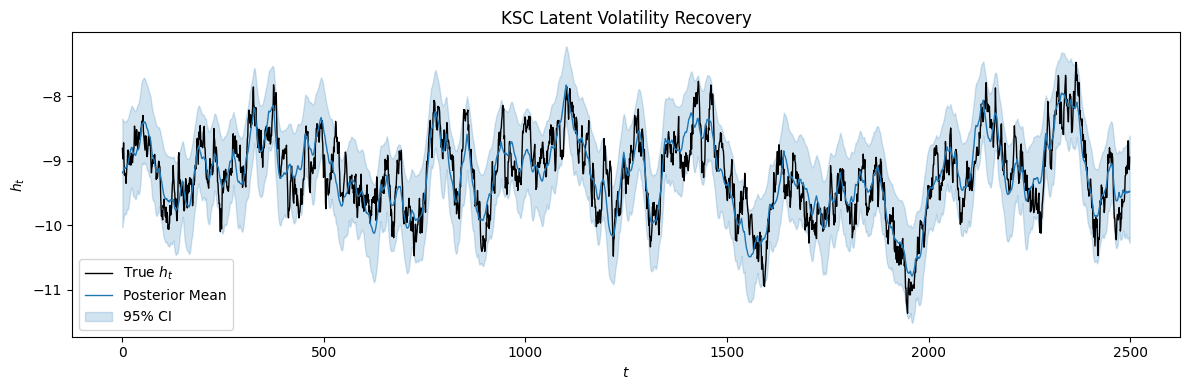

In [8]:
plot_latent_recovery(ksc_sim, h_sim, title="KSC Latent Volatility Recovery")
save_ksc_result("samples/ksc_sim.npz", ksc_sim)

The sampler also gives a reasonable estimate of the hidden volatility path. The posterior mean follows the true simulated path, and the interval shows the uncertainty around it. I save these results so they can be used as the reference later.

KSC Gibbs: 100%|██████████| 120000/120000 [02:04<00:00, 962.60it/s, chain=4/4, mu=-9.720, phi=0.9602, seed=1342, sigma_eta=0.306] 


KSC GSPC


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-9.660,0.175,-9.985,-9.322,0.001,0.001,75063.0,79590.0,1.0
phi,0.967,0.007,0.953,0.980,0.000,0.000,2604.0,7423.0,1.0
sigma_eta,0.274,0.023,0.231,0.319,0.001,0.000,1144.0,2005.0,1.0
h_mid,-9.969,0.458,-10.815,-9.088,0.003,0.001,26992.0,47637.0,1.0
h_last,-10.181,0.570,-11.270,-9.125,0.003,0.002,26762.0,45946.0,1.0


mu           602.136385
phi           20.888629
sigma_eta      9.176878
h_mid        216.522991
h_last       214.677989
Name: ess_bulk_per_sec, dtype: float64

accept_phi: [0.9558  0.95816 0.9572  0.95756]
Elapsed seconds: 124.66112649999923


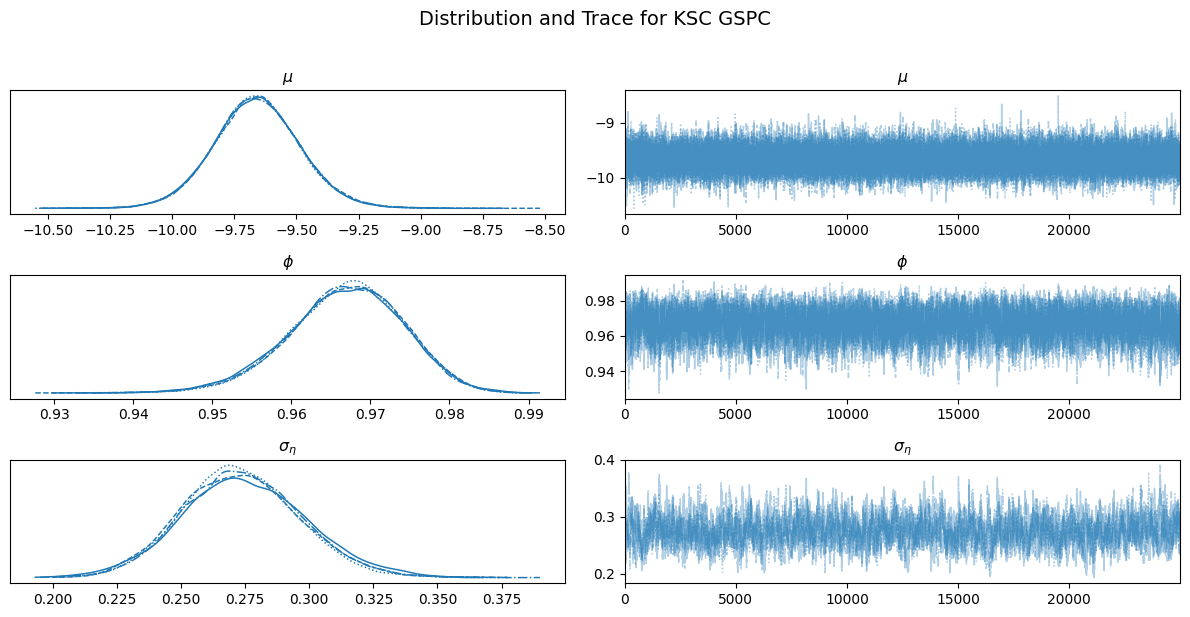

KSC Gibbs: 100%|██████████| 120000/120000 [02:03<00:00, 969.15it/s, chain=4/4, mu=-8.527, phi=0.9142, seed=1342, sigma_eta=0.379] 


KSC AAPL


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-8.487,0.104,-8.685,-8.293,0.001,0.000,29418.0,59917.0,1.0
phi,0.925,0.016,0.895,0.954,0.001,0.000,978.0,2554.0,1.0
sigma_eta,0.360,0.039,0.285,0.433,0.002,0.001,674.0,1382.0,1.0
h_mid,-7.865,0.533,-8.846,-6.838,0.003,0.002,27638.0,49924.0,1.0
h_last,-9.879,0.695,-11.159,-8.566,0.005,0.002,22629.0,46213.0,1.0


mu           237.589703
phi            7.898658
sigma_eta      5.443452
h_mid        223.213822
h_last       182.759446
Name: ess_bulk_per_sec, dtype: float64

accept_phi: [0.97028 0.9696  0.96988 0.97112]
Elapsed seconds: 123.81849712700205


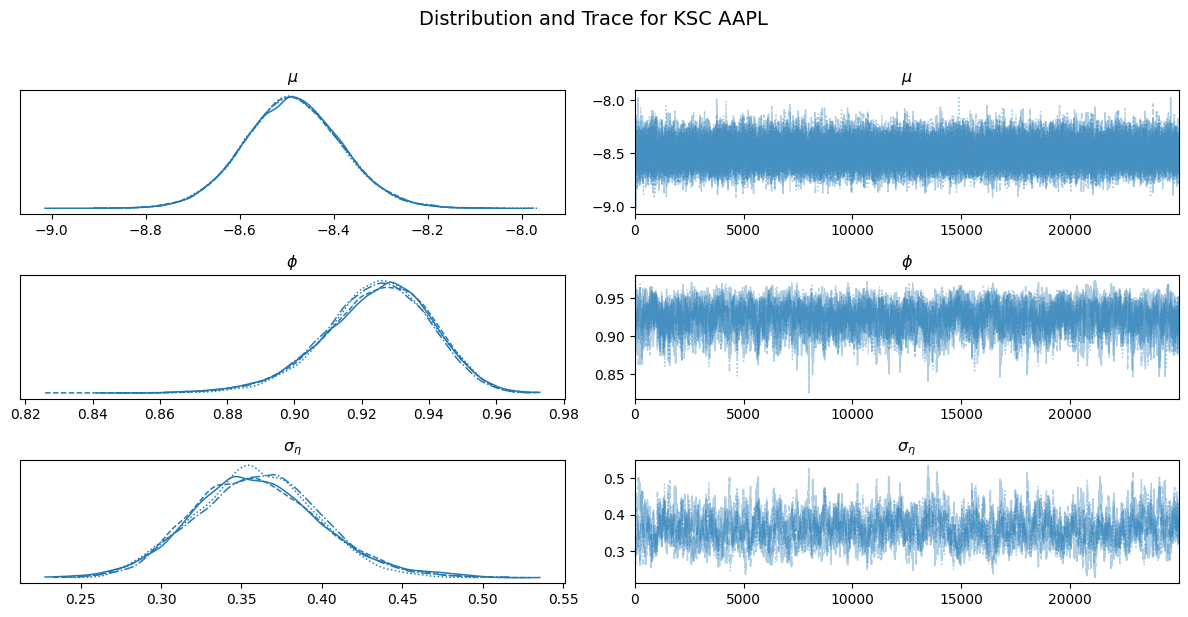

In [9]:
# Run KSC on yfinance data
def run_save_diagnose_ksc(label, y):
    result = run_ksc_chains(
        np.asarray(y),
        n_chains=KSC_N_CHAINS,
        n_iter=KSC_N_ITER,
        n_burn=KSC_N_BURN,
        prior_mu_var=PRIOR_MU_VAR,
        prior_sigma2_eta_gamma=PRIOR_SIGMA_ETA_GAMMA,
        prior_phi_beta=PRIOR_PHI_BETA,
        q=KSC_Q,
        m=KSC_M,
        v2=KSC_V2,
        seed=SEED + 1000,
        seed_stride=100,
        verbose=True,
        summarize_h_path=False
    )

    idata = display_sampler_diagnostics(
        f"KSC {label}",
        result,
        accept_key="accept_phi"
    )

    save_ksc_result(f"samples/ksc_{label.lower()}.npz", result)
    return result, idata


ksc_gspc, ksc_gspc_idata = run_save_diagnose_ksc("GSPC", log_returns_demeaned["^GSPC"].values)
ksc_aapl, ksc_aapl_idata = run_save_diagnose_ksc("AAPL", log_returns_demeaned["AAPL"].values)

---

## 4. NUTS via PyMC

KSC Gibbs is highly specialized for the stochastic volatility model, but it depends on the Kim-Shephard-Chib mixture approximation and a custom FFBS update. As a second benchmark, I fit the same stochastic volatility model using NUTS in PyMC. This gives a strong general-purpose Bayesian baseline: the model can be written directly, and NUTS uses gradient-based Hamiltonian dynamics to explore the posterior.

### Non-Centered Latent Parameterization

The NUTS implementation uses a non-centered representation of the latent volatility process. Instead of sampling the hidden path $h_{1:T}$ directly, PyMC samples standard Normal innovations $z_{1:T}$ and reconstructs the volatility path deterministically through the AR(1) recursion.

In conceptual terms, the sampler works with

$$
z_t \sim N(0,1)
$$

and then reconstructs

$$
h_t = \mu + \phi(h_{t-1} - \mu) + \sigma_\eta z_t.
$$

The initial latent state is handled consistently with the stationary AR(1) distribution used in the model.

This reparameterization changes the geometry of the posterior. In the centered version, the latent states and parameters are strongly coupled, especially when $\phi$ is close to one. The non-centered version moves much of that dependence into a deterministic transformation. This usually makes the posterior easier for gradient-based samplers like NUTS, because the sampler moves in a space of approximately standard Normal innovations rather than directly in a highly persistent latent path.

### Sampling Setup

The PyMC model uses the same priors as the other samplers so that differences in the results come from the inference method rather than from the prior specification. NUTS is run with the NumPyro backend for speed, multiple chains, and a high target acceptance rate. The higher target acceptance rate makes NUTS take more conservative leapfrog steps, which is useful for the funnel-like geometry created by the latent volatility process.

After sampling, the posterior draws are converted into the same result format used by the rest of the project. The saved NUTS result contains posterior draws for $\mu$, $\phi$, and $\sigma_\eta$, along with reconstructed latent-volatility summaries such as `h_mid`, `h_last`, and `h_mean`. This makes NUTS directly comparable to KSC Gibbs and flowMC in the final comparison section.

### Diagnostics

The main diagnostics for this step are posterior recovery on simulated data, R-hat, effective sample size, trace behavior, and divergences. On the simulated data, NUTS should recover the known truth for $\mu$, $\phi$, and $\sigma_\eta$. On real data, it serves as a flexible benchmark that does not rely on the KSC mixture approximation.

The main downside is computational cost. NUTS is sampling a posterior that includes thousands of latent innovations, so even with the non-centered parameterization it is still solving a high-dimensional problem. However, in the final comparison, NUTS gives clean convergence diagnostics and strong posterior agreement with KSC, making it the strongest general-purpose baseline in the project.


In [11]:
def build_pymc_sv_model(y_obs, prior_mu_var, prior_phi_beta, prior_sigma_eta_gamma):
    def ar_step(z_t, h_prev, mu, phi, sigma_eta):
            return mu + phi * (h_prev - mu) + sigma_eta * z_t
        
    T = len(y_obs)
    alpha_phi, beta_phi = prior_phi_beta
    alpha_se, beta_se = prior_sigma_eta_gamma
    
    with pm.Model() as model:
        # Priors
        mu = pm.Normal('mu', mu=0, sigma=np.sqrt(prior_mu_var))
        
        phi_star = pm.Beta('phi_star', alpha=alpha_phi, beta=beta_phi)
        phi = pm.Deterministic('phi', 2 * phi_star - 1)
        
        sigma2_eta = pm.InverseGamma('sigma2_eta', alpha=alpha_se, beta=beta_se)
        sigma_eta = pm.Deterministic('sigma_eta', pm.math.sqrt(sigma2_eta))
        
        # Non-centered AR(1) parametrization (required for convergence)
        z0 = pm.Normal('z0', 0.0, 1.0)
        z = pm.Normal('z', 0.0, 1.0, shape=T-1)
        
        # Latent path h
        h_0 = mu + sigma_eta / pt.sqrt(1.0 - phi**2) * z0
        h_tail = scan(fn=ar_step, sequences=z, outputs_info=h_0,
                      non_sequences=[mu, phi, sigma_eta], return_updates=False)
        h = pm.Deterministic("h", pt.concatenate([h_0[None], h_tail]))
        
        # Observation likelihood
        pm.Normal('y', mu=0, sigma=pm.math.exp(h / 2), observed=y_obs)
    
    return model

def nuts_result_from_trace(trace, elapsed_sec=None, seed=None):
    h = trace.posterior["h"].values
    mid = h.shape[-1] // 2

    return {
        "mu": trace.posterior["mu"].values.astype(np.float32),
        "phi": trace.posterior["phi"].values.astype(np.float32),
        "sigma_eta": trace.posterior["sigma_eta"].values.astype(np.float32),
        "h_mid": h[:, :, mid].astype(np.float32),
        "h_last": h[:, :, -1].astype(np.float32),
        "h_mean": h.reshape(-1, h.shape[-1]).mean(axis=0).astype(np.float32),
        "h_ci": np.quantile(h.reshape(-1, h.shape[-1]), [0.025, 0.975], axis=0).astype(np.float32),
        "divergences": int(trace.sample_stats["diverging"].values.sum()),
        "elapsed_sec": elapsed_sec,
        "n_chains": h.shape[0],
        "n_draws": h.shape[1],
        "n_dim": h.shape[-1] + 3,
        "seed": seed
    }

def save_nuts_result(path, result):
    np.savez_compressed(path, **result)

I check NUTS on the simulated data before using it on real data. The main things to look at are, as before, whether it recovers the true parameters, whether R-hat is close to 1, whether ESS is large enough, and whether there are divergences.

In [14]:
pymc_args = (PRIOR_MU_VAR, PRIOR_PHI_BETA, PRIOR_SIGMA_ETA_GAMMA)

t0 = time.time()
trace_sim = pm.sample(
    model=build_pymc_sv_model(y_sim, *pymc_args),
    draws=NUTS_DRAWS,
    tune=NUTS_TUNE,
    target_accept=NUTS_TARGET_ACCEPT,
    chains=4,
    cores=4,
    random_seed=SEED,
    nuts_sampler="numpyro",
    progressbar=True
)
nuts_sim = nuts_result_from_trace(trace_sim, elapsed_sec=time.time() - t0, seed=SEED)
save_nuts_result("samples/nuts_sim.npz", nuts_sim)

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

NUTS SIM


,mean,sd,2.5%,97.5%,truth,in CI
param,,,,,,
mu,-9.232713,0.114253,-9.451280,-8.998800,-9.00,True
phi,0.968703,0.008452,0.950076,0.982944,0.97,True
sigma_eta,0.160463,0.020872,0.122833,0.205257,0.15,True


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-9.233,0.114,-9.443,-9.012,0.001,0.001,9014.0,5690.0,1.0
phi,0.969,0.008,0.953,0.984,0.000,0.000,3156.0,5014.0,1.0
sigma_eta,0.160,0.021,0.119,0.197,0.000,0.000,3152.0,5280.0,1.0
h_mid,-9.158,0.348,-9.812,-8.505,0.003,0.003,13340.0,7765.0,1.0
h_last,-9.459,0.417,-10.244,-8.672,0.004,0.005,12662.0,5950.0,1.0


mu           204.421514
phi           71.572476
sigma_eta     71.481763
h_mid        302.527512
h_last       287.151676
Name: ess_bulk_per_sec, dtype: float64

Divergences: 0
Elapsed seconds: 44.095163106918335


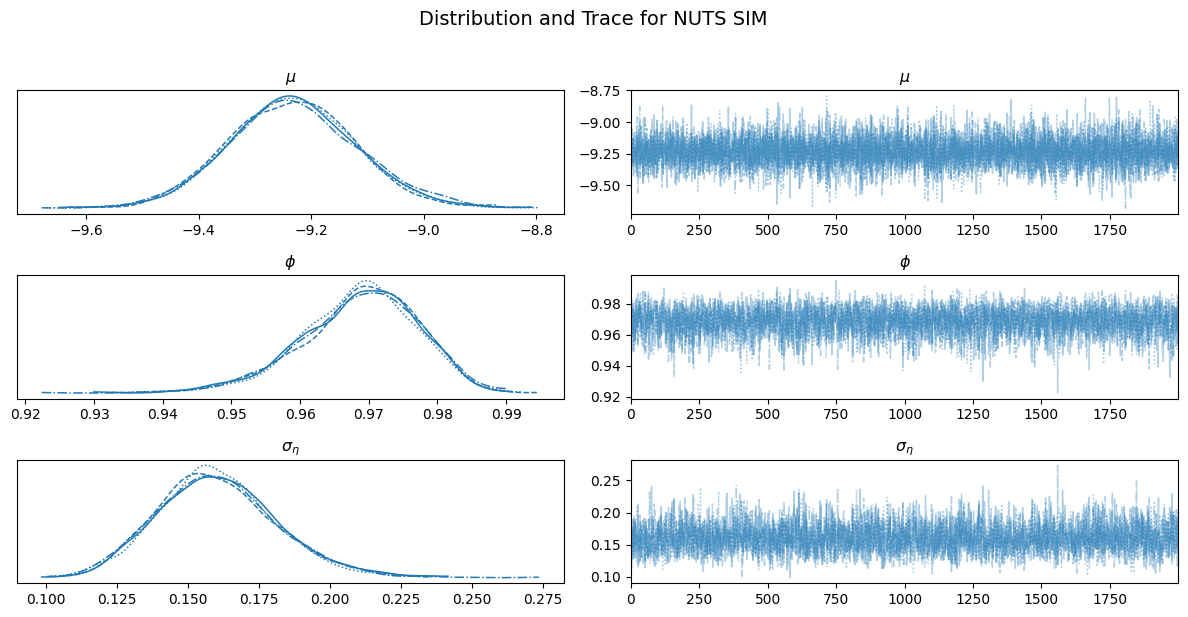

In [15]:
nuts_sim_idata = display_sampler_diagnostics(
    "NUTS SIM",
    nuts_sim,
    truth={"mu": MU_TRUE, "phi": PHI_TRUE, "sigma_eta": SIGMA_ETA_TRUE}
)

After checking NUTS on the simulated data, I run it on GSPC and AAPL. Since the true parameters are not known for real data, I mainly look at the convergence diagnostics and save the results for comparison later.

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

NUTS GSPC


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-9.695,0.176,-10.024,-9.365,0.003,0.002,3543.0,4230.0,1.0
phi,0.965,0.008,0.951,0.979,0.000,0.000,1670.0,3020.0,1.0
sigma_eta,0.292,0.026,0.246,0.342,0.001,0.000,1920.0,3432.0,1.0
h_mid,-9.980,0.478,-10.843,-9.039,0.005,0.005,10202.0,7068.0,1.0
h_last,-10.222,0.595,-11.350,-9.113,0.005,0.006,12711.0,6048.0,1.0


mu            78.790304
phi           37.137964
sigma_eta     42.697540
h_mid        226.875157
h_last       282.671056
Name: ess_bulk_per_sec, dtype: float64

Divergences: 0
Elapsed seconds: 44.96746206283569


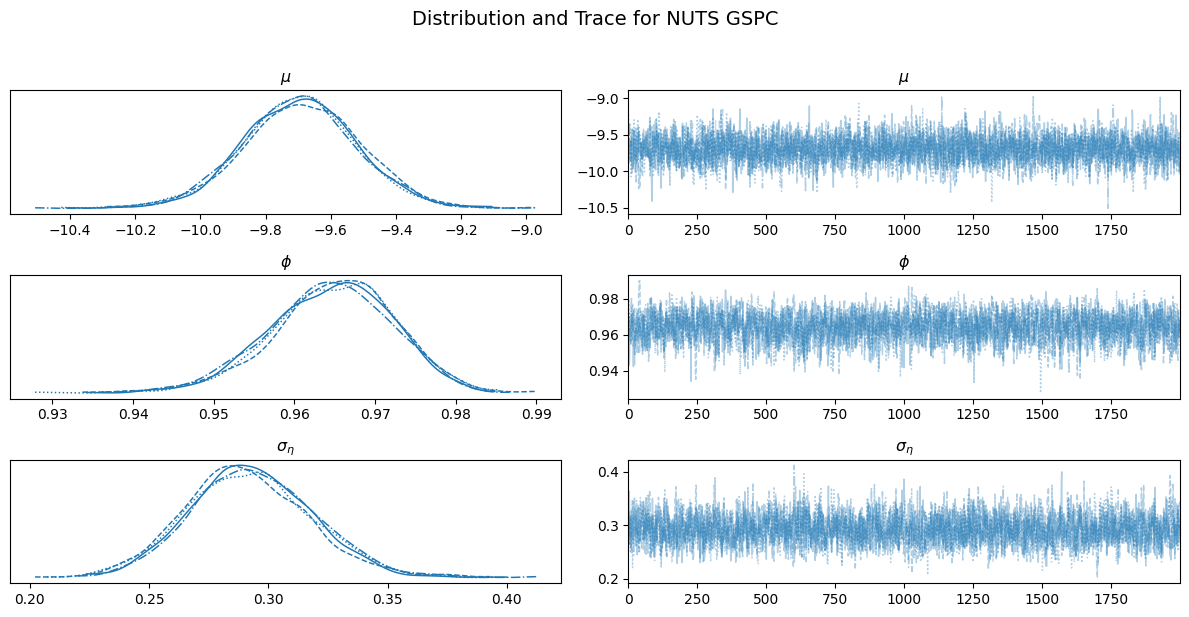

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

NUTS AAPL


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-8.501,0.103,-8.705,-8.316,0.001,0.001,7941.0,5935.0,1.0
phi,0.924,0.016,0.894,0.953,0.000,0.000,2183.0,3953.0,1.0
sigma_eta,0.361,0.040,0.290,0.438,0.001,0.001,1873.0,3632.0,1.0
h_mid,-7.871,0.528,-8.862,-6.867,0.005,0.005,12341.0,6881.0,1.0
h_last,-9.876,0.703,-11.215,-8.573,0.005,0.008,16516.0,6044.0,1.0


mu           187.055972
phi           51.422137
sigma_eta     44.119863
h_mid        290.701140
h_last       389.046270
Name: ess_bulk_per_sec, dtype: float64

Divergences: 0
Elapsed seconds: 42.45253396034241


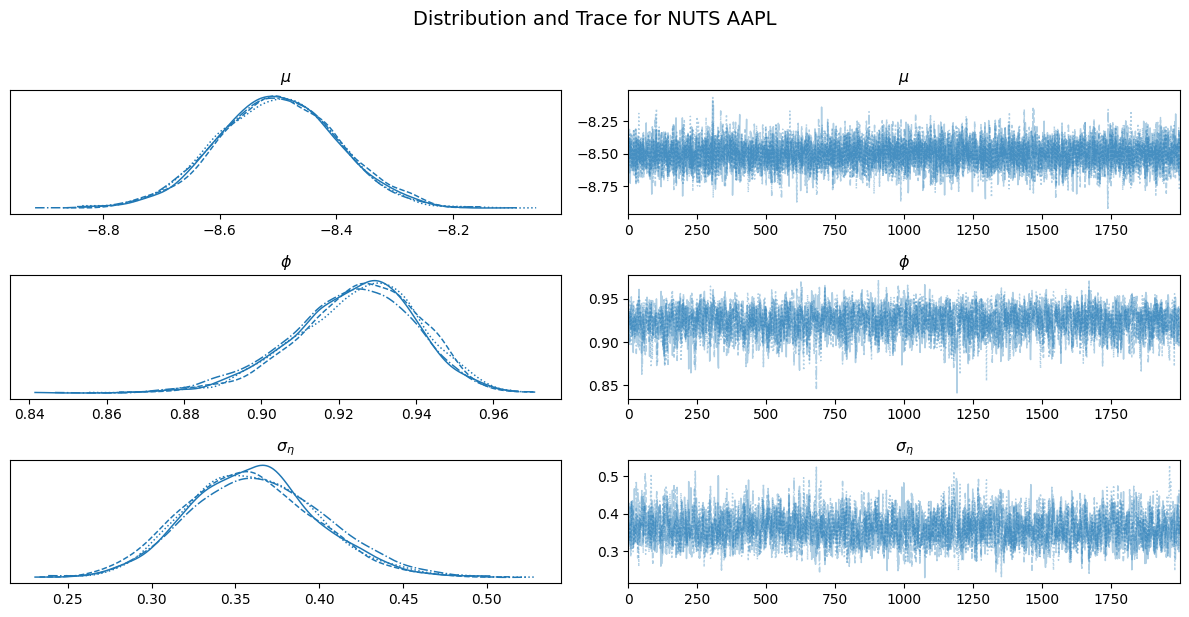

In [16]:
def run_save_diagnose_nuts(label, y):
    t0 = time.time()
    trace = pm.sample(
        model=build_pymc_sv_model(np.asarray(y), *pymc_args),
        draws=NUTS_DRAWS,
        tune=NUTS_TUNE,
        target_accept=NUTS_TARGET_ACCEPT,
        chains=4,
        cores=4,
        random_seed=SEED + 2000,
        nuts_sampler="numpyro"
    )

    result = nuts_result_from_trace(trace, elapsed_sec=time.time() - t0, seed=SEED + 2000)
    save_nuts_result(f"samples/nuts_{label.lower()}.npz", result)
    idata = display_sampler_diagnostics(f"NUTS {label}", result)

    return result, idata


nuts_gspc, nuts_gspc_idata = run_save_diagnose_nuts("GSPC", log_returns_demeaned["^GSPC"].values)
nuts_aapl, nuts_aapl_idata = run_save_diagnose_nuts("AAPL", log_returns_demeaned["AAPL"].values)

---

## 5. Flow-Augmented MCMC (flowMC)

KSC ([Step 3](#3-ksc-mixture-of-normals-gibbs-sampler)) handles the stochastic volatility posterior by exploiting model structure through mixture augmentation and FFBS. NUTS ([Step 4](#4-nuts-via-pymc)) handles the same posterior with gradient-based Hamiltonian dynamics and the non-centered latent representation introduced there. flowMC takes a third approach: it keeps the same non-centered target from Step 4, but replaces Hamiltonian dynamics with local MALA moves plus a learned normalizing-flow proposal.

The goal of flow-augmented MCMC is to use the chain history to train a proposal distribution that approximates the posterior. If the learned proposal is accurate enough, it can generate large independent moves across the posterior, potentially improving mixing relative to purely local samplers.

The flowMC sampler alternates between three operations:

1. **Local sampler**: MALA steps move each chain locally using gradient information from the log posterior.
2. **Global sampler**: the trained normalizing flow proposes an independent global move, which is accepted or rejected with a Metropolis-Hastings correction.
3. **Flow training**: the rational-quadratic spline flow is trained on recent chain states so that later global proposals better match the posterior.

### Architecture Choices

| Choice | Value | Rationale |
|---|---|---|
| Flow family | **Rational-quadratic spline** | More expressive than affine coupling flows and available through flowMC's spline bundles. |
| Local sampler | **MALA** | Uses gradient information and moved more effectively than a Gaussian random walk in this posterior. |
| `n_chains` | **64** | flowMC pools across chains for training data, so more chains give the flow a broader view of the posterior. |
| Step-size adaptation | `adapt_step_size=True` | The target has mixed scales across $\mu$, $\tanh^{-1}\phi$, $\log\sigma_\eta$, and the latent innovations. |
| Parallelism | **Modal B200** | The simulated data, GSPC, and AAPL runs are launched in parallel. |

### Reuse of the Step 4 Non-Centered Representation

As in the NUTS implementation from [Step 4](#4-nuts-via-pymc), flowMC samples standard Normal latent innovations $z_{1:T}$ rather than the volatility path $h_{1:T}$ directly. The volatility path is reconstructed deterministically through the same AR(1) recursion used in Step 4.

This keeps NUTS and flowMC comparable: both target the same posterior geometry in the same non-centered coordinates. The difference is how they move through that space. NUTS uses Hamiltonian dynamics, while flowMC uses local MALA steps and a trained independent flow proposal.

The flowMC-specific requirement is that this target must be written manually as a JAX log posterior on an unconstrained vector.

### Unconstrained State

flowMC operates on an unconstrained Euclidean vector. The sampled state is

$$
x =
\big(
\mu,\;
\phi_{\text{raw}},\;
\ell_\sigma,\;
z_1,\ldots,z_T
\big)
\in \mathbb R^{T+3}.
$$

The constrained parameters are recovered by

$$
\phi = \tanh(\phi_{\text{raw}}),
\qquad
\sigma_\eta = \exp(\ell_\sigma).
$$

The $\tanh$ transformation keeps $\phi$ inside $(-1,1)$, and the exponential transformation keeps $\sigma_\eta$ positive.

Because these are changes of variables, the log posterior includes the Jacobian correction

$$
\log(1 - \phi^2) + \ell_\sigma.
$$

The likelihood is evaluated by reconstructing $h_{1:T}$ from $(\mu,\phi,\sigma_\eta,z_{1:T})$ and computing the stochastic volatility observation density.

### Output Conversion

After sampling, `run_flow_mcmc` converts the unconstrained parameters back to $\phi$ and $\sigma_\eta$. It also reconstructs the latent volatility path from each retained draw. To avoid excessive memory use, the saved result stores the parameter chains and only the latent summaries needed for comparison, including `h_mid`, `h_last`, `h_mean`, and `h_ci`.

These summaries make flowMC comparable to KSC and NUTS in the final comparison section without saving the full latent path for every draw.

### Main Diagnostic Finding

The main empirical finding from this step is that the local MALA component worked, but the global flow proposal did not.

After tuning, the local MALA sampler produced usable simulated-data draws. In the final simulated run, the parameter R-hats were around `1.05` to `1.08`, and the local acceptance rate was about `0.58`.

However, the global flow acceptance stayed at `0.00`. This means the trained independent flow proposal was not close enough to the high-dimensional joint posterior to pass the Metropolis-Hastings correction.

In practice, flowMC behaved mostly like a tuned local MALA sampler rather than a genuinely flow-accelerated sampler. This is especially visible on the real datasets, where the flowMC parameter R-hats were weaker than KSC and NUTS. The conclusion is not that flow-based MCMC is useless, but that a single global proposal over parameters and thousands of latent innovations is too difficult for this implementation. A better flow design would likely use blocked latent updates, parameter-only global proposals, or conditional flows.


In [17]:
import modal

if modal.config.config.get("token_id") is None:
    !modal token new

# Modal overlay on flow_mcmc.py methods.
app = modal.App("sv-flow")
image = (
    modal.Image
    .debian_slim("3.13")
    .pip_install("flowmc")
    .pip_install("jax[cuda13]")
    .add_local_python_source("src")
)

flowMC SIM


,mean,sd,2.5%,97.5%,truth,in CI
param,,,,,,
mu,-9.236058,0.112611,-9.459718,-9.008152,-9.00,False
phi,0.968515,0.008563,0.949249,0.983144,0.97,True
sigma_eta,0.160741,0.020605,0.123841,0.204264,0.15,True


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-9.236,0.113,-9.449,-9.021,0.005,0.003,557.0,1080.0,1.08
phi,0.969,0.009,0.953,0.984,0.000,0.000,606.0,1524.0,1.08
sigma_eta,0.161,0.021,0.123,0.200,0.001,0.000,662.0,2109.0,1.07
h_mid,-9.153,0.351,-9.815,-8.488,0.008,0.004,1819.0,4588.0,1.03
h_last,-9.454,0.417,-10.241,-8.668,0.014,0.005,914.0,3203.0,1.05


mu           0.286056
phi          0.311221
sigma_eta    0.339981
h_mid        0.934177
h_last       0.469399
Name: ess_bulk_per_sec, dtype: float64

Elapsed seconds: 1947.1690410850001


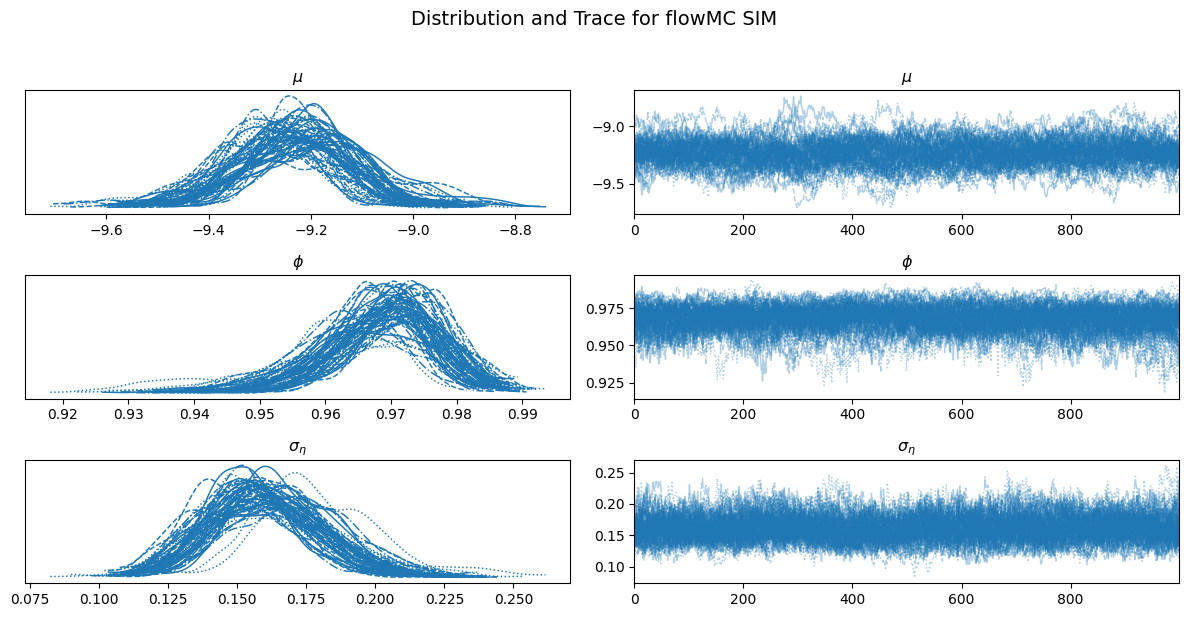

local accept: 0.58128834
global accept: 0.0
final loss/dim: 1.4000669
flowMC GSPC


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-9.710,0.178,-10.024,-9.346,0.015,0.010,135.0,175.0,1.41
phi,0.966,0.007,0.952,0.980,0.001,0.000,167.0,261.0,1.30
sigma_eta,0.290,0.026,0.242,0.341,0.002,0.001,209.0,514.0,1.22
h_mid,-9.981,0.464,-10.835,-9.092,0.025,0.008,355.0,1053.0,1.12
h_last,-10.222,0.589,-11.272,-9.067,0.025,0.011,539.0,1491.0,1.08


mu           0.110965
phi          0.137267
sigma_eta    0.171790
h_mid        0.291796
h_last       0.443037
Name: ess_bulk_per_sec, dtype: float64

Elapsed seconds: 1216.6039470819999


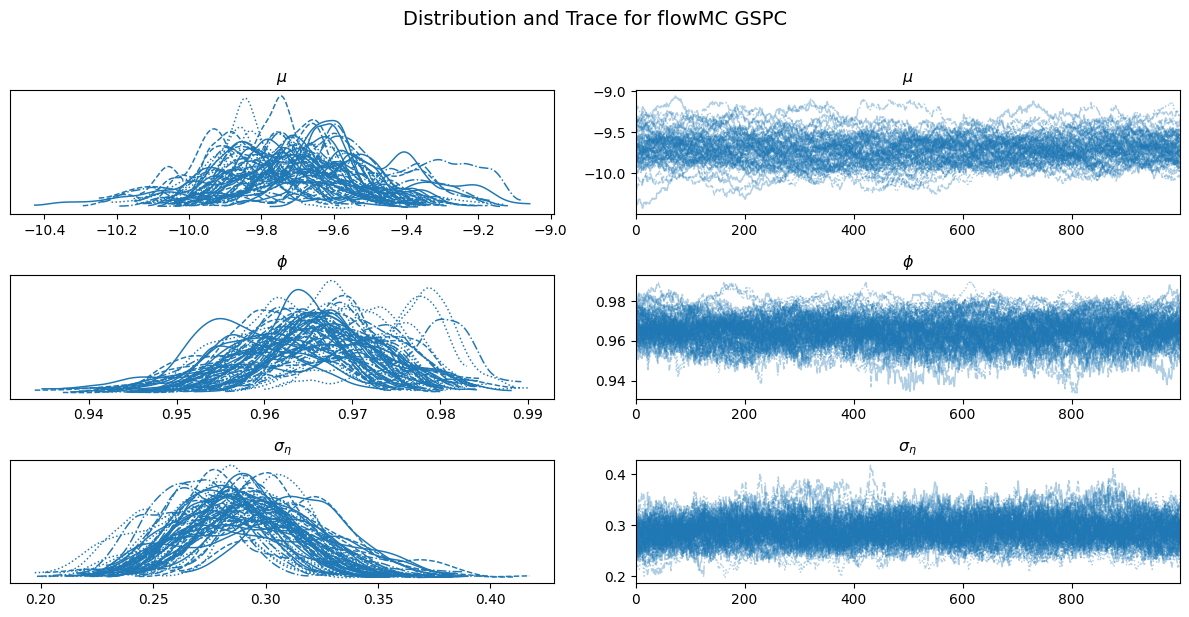

local accept: 0.5693662
global accept: 0.0
final loss/dim: 1.2822081
flowMC AAPL


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-8.509,0.102,-8.698,-8.317,0.006,0.003,285.0,624.0,1.16
phi,0.926,0.016,0.895,0.955,0.001,0.001,151.0,323.0,1.34
sigma_eta,0.358,0.039,0.284,0.434,0.003,0.002,169.0,301.0,1.29
h_mid,-7.874,0.516,-8.853,-6.918,0.024,0.009,453.0,1334.0,1.10
h_last,-9.866,0.703,-11.147,-8.524,0.029,0.013,599.0,1783.0,1.08


mu           0.107565
phi          0.056990
sigma_eta    0.063784
h_mid        0.170971
h_last       0.226075
Name: ess_bulk_per_sec, dtype: float64

Elapsed seconds: 2649.566060338


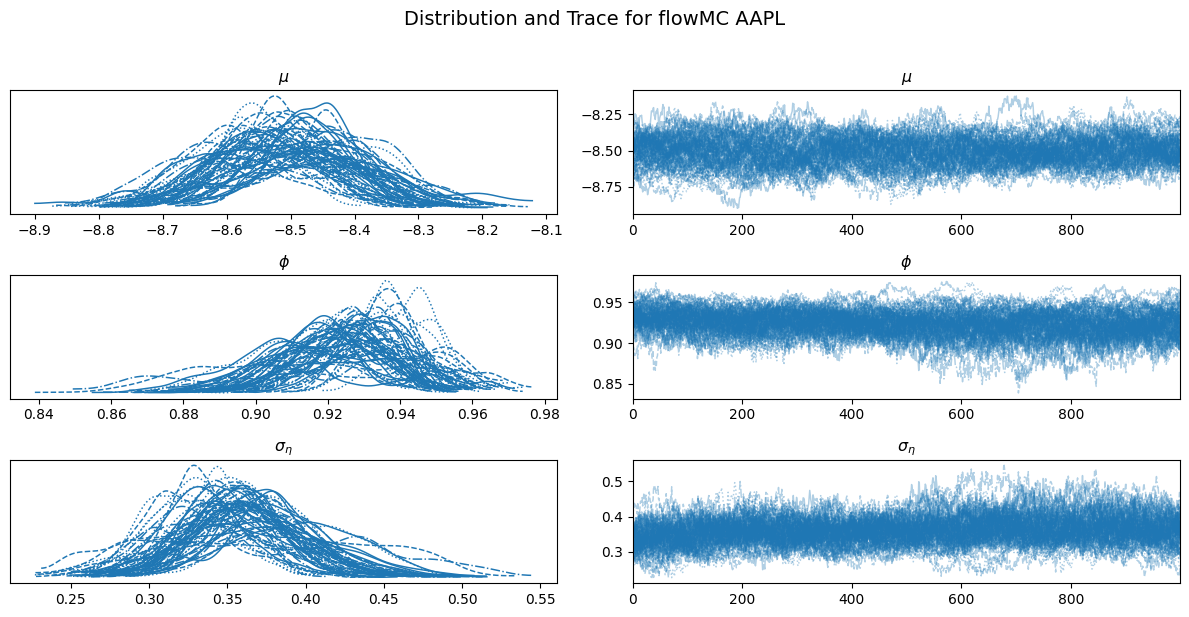

local accept: 0.56585884
global accept: 0.0
final loss/dim: 1.3451037


In [ ]:
# Modal wrapper
@app.function(gpu=MODAL_GPU, image=image, timeout=10800)
def run_flow_mcmc_modal(y_obs, **kwargs):
    from src.flow_mcmc import run_flow_mcmc
    result = run_flow_mcmc(y_obs, **kwargs)
    return result

with app.run():
    futures = {}

    run_kwargs = dict(
        local_kernel=FLOW_LOCAL_KERNEL,
        n_chains=FLOW_N_CHAINS,
        n_hidden=FLOW_N_HIDDEN,
        n_local=FLOW_N_LOCAL,
        n_global=FLOW_N_GLOBAL,
        n_training=FLOW_N_TRAINING,
        n_production=FLOW_N_PRODUCTION,
        n_epochs=FLOW_N_EPOCHS,
        theta_init=FLOW_INIT_THETA,
        theta_init_scale=FLOW_THETA0_SCALE,
        mala_step_size=FLOW_MALA_STEPSIZE,
        adapt_step_size=True,
        local_thinning=FLOW_LOCAL_THINNING,
        max_stored_draws=FLOW_MAX_STORED_DRAWS,
    )

    futures["SIM"] = run_flow_mcmc_modal.spawn(y_sim, **run_kwargs)
    futures["GSPC"] = run_flow_mcmc_modal.spawn(log_returns_demeaned["^GSPC"].values, **run_kwargs)
    futures["AAPL"] = run_flow_mcmc_modal.spawn(log_returns_demeaned["AAPL"].values, **run_kwargs)

    results_by_dataset = {}
    for name, future in futures.items():
        result = future.get()
        results_by_dataset[name] = result
        np.savez_compressed(f"samples/flow_{name.lower()}.npz", **result)

for name, result in results_by_dataset.items():
    truth = None
    if name == "SIM":
        truth = {"mu": MU_TRUE, "phi": PHI_TRUE, "sigma_eta": SIGMA_ETA_TRUE}
    display_flow_diagnostics(f"flowMC {name}", result, truth=truth)

---

## 6. Comparison Metrics

In this step, we compare the three samplers from the previous sections: KSC Gibbs ([Step 3](#3-ksc-mixture-of-normals-gibbs-sampler)), NUTS ([Step 4](#4-nuts-via-pymc)), and flowMC ([Step 5](#5-flow-augmented-mcmc-flowmc)). The comparison uses the saved posterior draws rather than rerunning the samplers. We capture three dimensions in the comparison:

1. **Mixing efficiency**. For each sampler, we compute bulk effective sample size per second. This measures how many useful posterior draws the sampler produces per second of runtime. We check this for the main parameters $\mu$, $\phi$, and $\sigma_\eta$, and also for one representative latent state $h_{T/2}$.

2. **Posterior agreement**. Since KSC is the specialized sampler for this stochastic volatility model, we use it as the reference posterior. For each other sampler, we compute marginal Wasserstein distance to KSC. Smaller Wasserstein distance means the sampler's marginal posterior is closer to the KSC posterior.

3. **Value-at-Risk task**. Using each sampler's posterior draws, we simulate posterior predictive returns and estimate one-day and ten-day VaR. We then compare the VaR forecasts against realized losses using the Kupiec unconditional coverage test. This checks whether the observed exceedance rate is close to the target tail probability.

For GSPC and AAPL, this is a realized-loss backtest, whereas for the simulated data from [Step 2](#2-generate-simulated-data-truth-set), it is only a posterior predictive calibration check, since the data is generated from the same model used for inference.

In [21]:
# Load all saved samples
sample_results = load_all_sampler_results(
    sample_dir="samples",
    datasets=("sim", "gspc", "aapl"),
    samplers=("ksc", "nuts", "flow")
)

available_samples = pd.DataFrame([
    {"dataset": dataset, "samplers": ", ".join(sorted(by_sampler))}
    for dataset, by_sampler in sample_results.items()
])
display(available_samples)

,dataset,samplers
0,sim,"flow, ksc, nuts"
1,gspc,"flow, ksc, nuts"
2,aapl,"flow, ksc, nuts"


,dataset,sampler,variable,ess_bulk,r_hat,elapsed_sec,ess_per_sec
0,sim,ksc,mu,56559.0,1.00,120.478924,469.451404
1,sim,ksc,phi,1038.0,1.00,120.478924,8.615615
2,sim,ksc,sigma_eta,565.0,1.01,120.478924,4.689617
3,sim,ksc,h_mid,30128.0,1.00,120.478924,250.068634
4,sim,nuts,mu,9014.0,1.00,44.095163,204.421514
5,sim,nuts,phi,3156.0,1.00,44.095163,71.572476
6,sim,nuts,sigma_eta,3152.0,1.00,44.095163,71.481763
7,sim,nuts,h_mid,13340.0,1.00,44.095163,302.527512
8,sim,flow,mu,557.0,1.08,1947.169041,0.286056
9,sim,flow,phi,606.0,1.08,1947.169041,0.311221


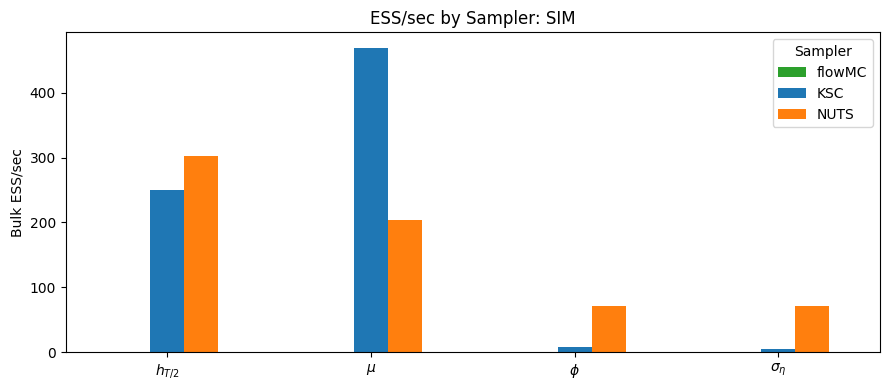

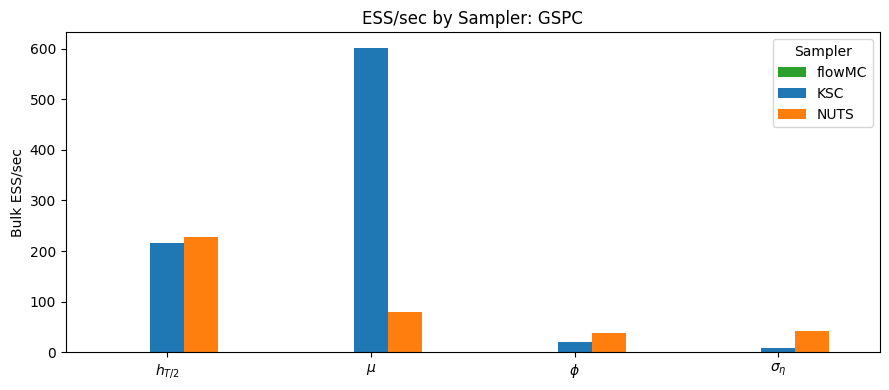

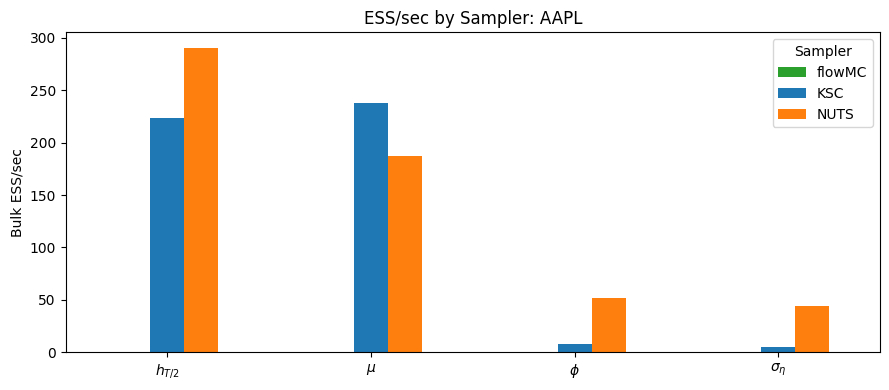

In [22]:
# 1. Mixing efficiency
ess_df = ess_per_second_table(sample_results)
display(ess_df)

for dataset in ("sim", "gspc", "aapl"):
    plot_ess_per_second(ess_df, dataset)

,dataset,sampler,variable,wasserstein_to_ksc
0,sim,ksc,mu,0.000000
1,sim,ksc,phi,0.000000
2,sim,ksc,sigma_eta,0.000000
3,sim,ksc,h_mid,0.000000
4,sim,nuts,mu,0.010974
5,sim,nuts,phi,0.000283
6,sim,nuts,sigma_eta,0.000418
7,sim,nuts,h_mid,0.015718
8,sim,flow,mu,0.014269
9,sim,flow,phi,0.000464


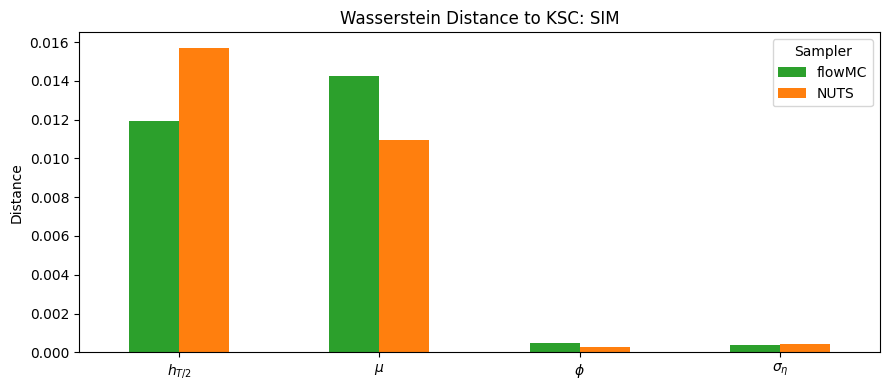

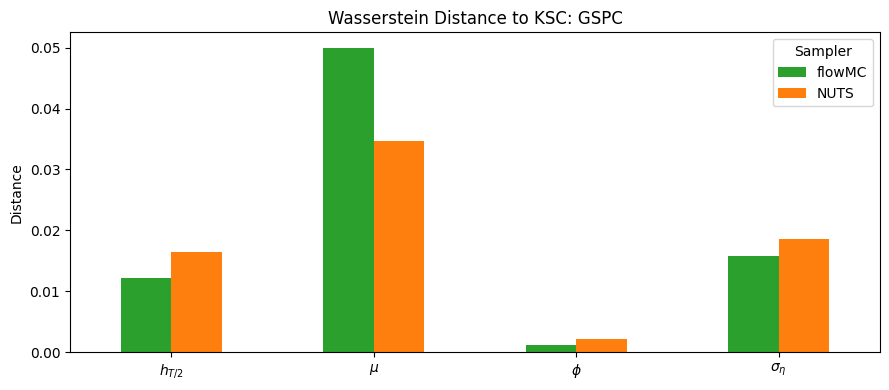

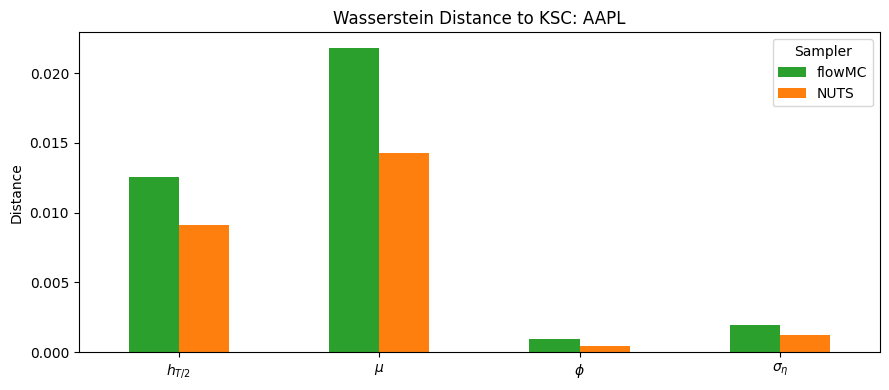

In [23]:
# 2. Posterior agreement
wasserstein_df = wasserstein_distance_table(sample_results, reference="ksc")
display(wasserstein_df)

for dataset in ("sim", "gspc", "aapl"):
    plot_wasserstein(wasserstein_df, dataset, reference="ksc")

,dataset,sampler,horizon,tail_prob,var,n_paths
0,sim,ksc,1,0.01,0.022563,50000
1,sim,ksc,1,0.05,0.015114,50000
2,sim,ksc,10,0.01,0.074814,50000
3,sim,ksc,10,0.05,0.048586,50000
4,sim,nuts,1,0.01,0.022903,50000
5,sim,nuts,1,0.05,0.015369,50000
6,sim,nuts,10,0.01,0.073516,50000
7,sim,nuts,10,0.05,0.049071,50000
8,sim,flow,1,0.01,0.022839,50000
9,sim,flow,1,0.05,0.015065,50000


,dataset,sampler,horizon,tail_prob,var,n_paths,n_obs,n_exceed,expected_exceed,exceed_rate,lr_uc,p_value
0,sim,ksc,1,0.01,0.022563,50000,2500,63,25.00,0.025200,41.043065,1.489116e-10
1,sim,ksc,1,0.05,0.015114,50000,2500,195,125.00,0.078000,35.511202,2.535880e-09
2,sim,ksc,10,0.01,0.074814,50000,2491,67,24.91,0.026897,49.125214,2.401335e-12
3,sim,ksc,10,0.05,0.048586,50000,2491,172,124.55,0.069049,17.096659,3.552475e-05
4,sim,nuts,1,0.01,0.022903,50000,2500,61,25.00,0.024400,37.349955,9.872318e-10
5,sim,nuts,1,0.05,0.015369,50000,2500,186,125.00,0.074400,27.425378,1.632745e-07
6,sim,nuts,10,0.01,0.073516,50000,2491,70,24.91,0.028101,55.301125,1.034094e-13
7,sim,nuts,10,0.05,0.049071,50000,2491,172,124.55,0.069049,17.096659,3.552475e-05
8,sim,flow,1,0.01,0.022839,50000,2500,61,25.00,0.024400,37.349955,9.872318e-10
9,sim,flow,1,0.05,0.015065,50000,2500,198,125.00,0.079200,38.408643,5.737773e-10


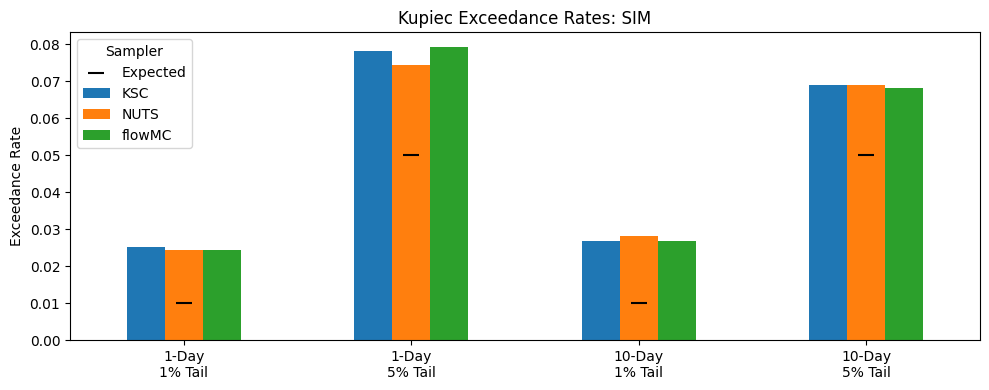

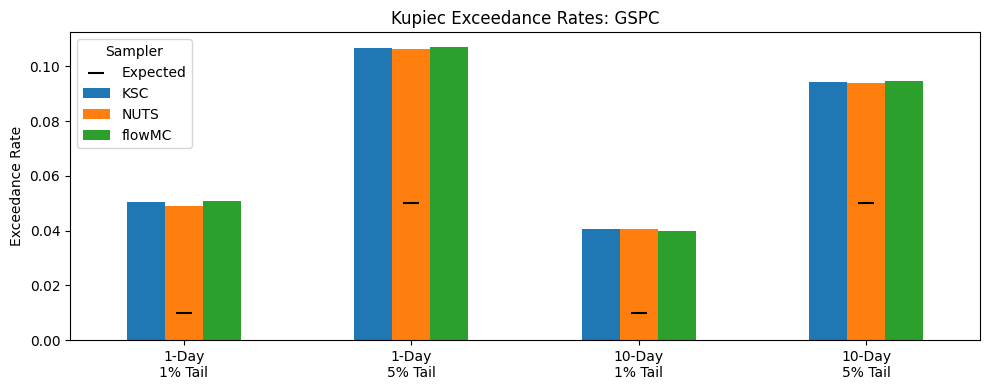

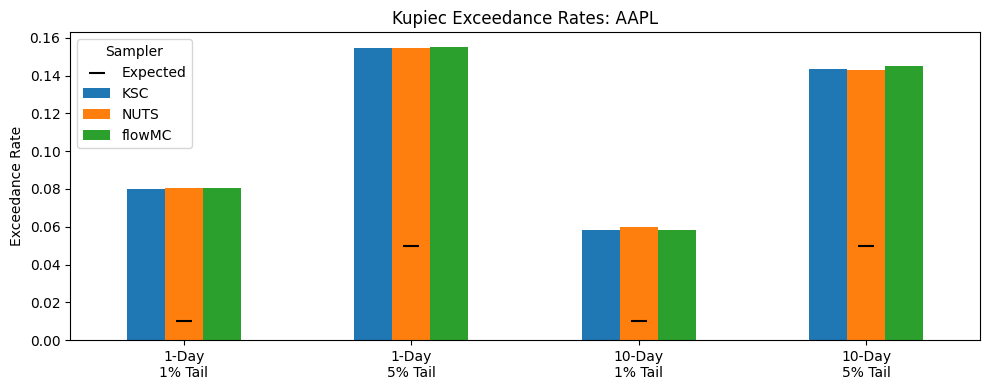

,sampler,mean_abs_exceed_error,median_kupiec_p_value
2,nuts,0.046982,4.890483e-30
1,ksc,0.047281,2.239290e-30
0,flow,0.047546,3.809454e-30


In [24]:
# 3. VAR estimate + backtest
returns_by_dataset = {
    "sim":  y_sim,
    "gspc": log_returns_demeaned["^GSPC"].values,
    "aapl": log_returns_demeaned["AAPL"].values
}

var_df = var_forecast_table(
    sample_results,
    datasets=("sim", "gspc", "aapl"),
    horizons=(1, 10),
    tail_probs=(0.01, 0.05),
    n_paths=50_000,
    seed=SEED
)
display(var_df)

kupiec_df = kupiec_backtest_table(var_df, returns_by_dataset)
display(kupiec_df)

for dataset in ("sim", "gspc", "aapl"):
    plot_kupiec_exceedance_rates(kupiec_df, dataset)
    
var_ranking = (
    kupiec_df
    .assign(abs_exceed_error=lambda df: (df["exceed_rate"] - df["tail_prob"]).abs())
    .groupby("sampler", as_index=False)
    .agg(
        mean_abs_exceed_error=("abs_exceed_error", "mean"),
        median_kupiec_p_value=("p_value", "median"),
    )
    .sort_values("mean_abs_exceed_error")
)

display(var_ranking)

## 7. Conclusion

This project compared three approaches to posterior inference for the stochastic volatility model: KSC Gibbs, PyMC/NUTS, and flowMC. The main result is that all three methods can target the same underlying model, but they behave very differently because they move through the posterior in different ways:

- **KSC Gibbs** was the most specialized method. It uses the Kim, Shephard, and Chib mixture approximation to turn the observation equation into a conditionally Gaussian state-space model, then samples the latent volatility path with FFBS. This makes the sampler fast and stable, but it also means the method depends on the mixture approximation.

- **NUTS** was the strongest general-purpose baseline. It does not use the KSC mixture approximation, and it samples the model directly using a non-centered latent innovation parameterization. This made it flexible and reliable, but also more computationally expensive because the sampler still has to explore a high-dimensional latent-state posterior.
- **flowMC** was the most experimental method. It used the same non-centered latent innovation idea as the PyMC model, but tried to improve sampling by training a normalizing-flow global proposal. In practice, the local MALA component produced usable samples after tuning, but the global flow proposal had near-zero acceptance. On the simulated data, flowMC still recovered the main parameters reasonably well, but the global acceptance rate was essentially zero. On the real datasets, the flowMC convergence diagnostics were weaker: parameter R-hats were around 1.28-1.37 for GSPC/AAPL, while KSC and NUTS were much closer to 1.0. This suggests that the learned independent proposal did not approximate the full high-dimensional posterior accurately enough, so flowMC mostly behaved like a tuned local sampler.

The VaR results also show an important modeling limitation: the Gaussian stochastic volatility model captures persistent volatility, but it does not fully capture the tail behavior of real financial returns. Across the real-data backtests, exceedance rates were often above the nominal level, which suggests that extensions such as heavy-tailed observation errors, leverage effects, jumps, or regime changes would be useful.

The conclusion from this project is that sampler choice matters, but model choice matters too. KSC and NUTS are strong benchmarks for this baseline SV model, and flowMC is promising as an idea, but for this problem the main next step is not simply to run it longer. The more useful direction is to change the latent-path update structure, for example with blocked or FFBS-style moves, or to make the flow learn a lower-dimensional or conditional target instead of the entire joint posterior at once.

## Appendix
### A. Known Limitations
This project compares KSC Gibbs, NUTS, and flowMC on the same stochastic volatility model, but the comparison is still limited in a few ways. First, the simulation study is based on a small number of simulated paths. This is enough to check whether the samplers can recover known parameters, but it is not enough to fully measure bias, coverage, runtime variability, or robustness. A larger repeated-simulation study would give a more stable picture of how the samplers behave across different latent volatility paths.

The model itself is also simplified. It captures the main idea of persistent latent volatility, but it does not explicitly include leverage effects, jumps, heavy-tailed observation errors, or regime changes. These features are common in real financial returns, so the real-data results should be interpreted as performance under a useful baseline model rather than as a complete description of market behavior.

Each sampler also has its own limitation. The KSC Gibbs sampler is fast and stable, but it relies on a mixture-of-normals approximation to the log-$\chi^2$ observation error. This approximation is standard and very accurate, but it is still an approximation. NUTS targets the stated model more directly, but it is computationally expensive because it samples the full latent volatility path along with the parameters. flowMC also uses the full latent-state posterior, and in this project its learned global proposal had near-zero acceptance. As a result, flowMC mostly relied on its local kernel, which limited the benefit of the normalizing-flow component.

### B. Future Considerations
The next step is not just to run the same flowMC sampler for longer. The main issue appears to be structural: the global flow proposal is trying to learn a very high-dimensional posterior over all latent volatility states at once, and in these runs that proposal was almost never accepted. A more useful direction would be to change how the sampler moves through the latent path. One option is to use blocked or FFBS-style updates, which are already effective in the KSC sampler. Another option is to make the flow learn a lower-dimensional or conditional target instead of the entire joint posterior.

Beyond flowMC, the comparison could also be strengthened by running repeated simulation studies. This would make it possible to evaluate bias, coverage, runtime variability, and stability across many latent volatility paths rather than one or two examples. The real-data analysis could also be expanded to more assets and market regimes, especially periods with unusually high volatility, where differences between samplers and model assumptions may matter more.

Finally, the model itself could be extended. A natural next step would be to add features such as heavy-tailed observation errors, leverage effects, jumps, or regime changes. These extensions would make the model more realistic for financial returns, but they would also make posterior inference harder, which would provide a stronger test of the samplers.

### C. GenAI Disclosure
Generative AI tools were used to assist with text and code cleanup, and creation of baseline of secondary files and functions, such as codebase setup, PyTests for correctness, visualization utilities, and diagnostic plots. GenAI was generally used for better understanding, and partial planning, debugging, optimization, and code suggestions. All primary project code, including the KSC sampler, the PyMC/NUTS model, the flowMC implementation, and the sampler comparison logic, was written by the author. Any suggestions and implementation from GenAI tools were independently reviewed, tested, and accepted before being formally included in the codebase.

## References

Abril-Pla, O., Andreani, V., Carroll, C., Dong, L., Fonnesbeck, C. J., Kochurov, M., Kumar, R., Lao, J., Luhmann, C. C., Martin, O. A., Osthege, M., Vieira, R., Wiecki, T., & Zinkov, R. (2023). PyMC: A modern, and comprehensive probabilistic programming framework in Python. *PeerJ Computer Science, 9*, e1516. https://doi.org/10.7717/peerj-cs.1516

Carter, C. K., & Kohn, R. (1994). On Gibbs sampling for state space models. *Biometrika, 81*(3), 541-553.

Durkan, C., Bekasov, A., Murray, I., & Papamakarios, G. (2019). Neural spline flows. *Advances in Neural Information Processing Systems, 32*.

Hoffman, M. D., & Gelman, A. (2014). The No-U-Turn sampler: Adaptively setting path lengths in Hamiltonian Monte Carlo. *Journal of Machine Learning Research, 15*(47), 1593-1623.

Kim, S., Shephard, N., & Chib, S. (1998). Stochastic volatility: Likelihood inference and comparison with ARCH models. *The Review of Economic Studies, 65*(3), 361-393.

Kumar, R., Carroll, C., Hartikainen, A., & Martin, O. (2019). ArviZ: A unified library for exploratory analysis of Bayesian models in Python. *Journal of Open Source Software, 4*(33), 1143. https://doi.org/10.21105/joss.01143

Kupiec, P. H. (1995). Techniques for verifying the accuracy of risk measurement models. *The Journal of Derivatives, 3*(2), 73-84. https://doi.org/10.3905/jod.1995.407942

Wong, K. W. K., Gabrié, M., & Foreman-Mackey, D. (2023). flowMC: Normalizing flow enhanced sampling package for probabilistic inference in JAX. *Journal of Open Source Software, 8*(83), 5021. https://doi.org/10.21105/joss.05021
